# Análise Exploratória e Modelos Preditivos — Produtos Agrícolas

**Fase 3 — Cap 10: A primeira técnica de aprendizado de máquina**

| | |
|---|---|
| **Grupo** | 71 |
| **Integrantes** | Lucas Michels Kuntz (RM 570050) · João Pedro Alencar (RM 573473) · Alisson Vinicius de Souza Rabelo Teixeira (RM 573512) |
| **Tutor(a)** | Sabrina Otoni |
| **Coordenador(a)** | André Godoi |
| **Entrega** | 19/05/2026 |

---

## Sumário
1. [Configuração e Carregamento dos Dados](#1)
2. [Análise Exploratória (EDA)](#2)
3. [Análise Descritiva com Gráficos](#3)
4. [Perfil Ideal de Solo/Clima e Comparação de Culturas](#4)
5. [Modelos Preditivos de Machine Learning](#5)
6. [Comparação de Modelos](#6)
7. [Conclusões](#7)

<a id='1'></a>
## 1. Configuração e Carregamento dos Dados

In [1]:
# Instalação de dependências (executar apenas se necessário)
# !pip install pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import pi

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = 'tab20'
SEED = 42

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
import os
from pathlib import Path

# Localiza o CSV dentro do próprio repositório (sem dependência externa)
_here = Path(os.getcwd())
_candidates = [
    _here / 'document' / 'Atividade_Cap10_produtos_agricolas.csv',   # rodando da raiz do repo
    _here.parent / 'document' / 'Atividade_Cap10_produtos_agricolas.csv',  # rodando de src/
]
DATA_PATH = next((str(p) for p in _candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV não encontrado. Certifique-se de que o arquivo está em document/ "
        "e que o notebook é executado a partir da raiz do repositório ou de src/."
    )

df = pd.read_csv(DATA_PATH)
print(f'CSV lido de: {DATA_PATH}')
print(f'Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

CSV lido de: C:\Users\kuntz\Documents\projects\fiap-fase3-cap10\document\Atividade_Cap10_produtos_agricolas.csv
Dataset carregado: 2200 linhas × 8 colunas


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<a id='2'></a>
## 2. Análise Exploratória (EDA)

Nesta seção investigamos a estrutura do dataset, tipos de variáveis, presença de valores ausentes e estatísticas descritivas básicas.

In [3]:
print('=== Tipos e Nulos ===')
print(df.info())
print('\n=== Valores Ausentes ===')
print(df.isnull().sum())
print('\n=== Duplicatas ===')
print(f'{df.duplicated().sum()} linhas duplicadas')

=== Tipos e Nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None

=== Valores Ausentes ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Duplicatas ===
0 linhas duplicadas


In [4]:
print('=== Estatísticas Descritivas ===')
df.describe().T.round(3)

=== Estatísticas Descritivas ===


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.552,36.917,0.000,21.000,37.000,84.250,140.000
P,2200.0,53.363,32.986,5.000,28.000,51.000,68.000,145.000
K,2200.0,48.149,50.648,5.000,20.000,32.000,49.000,205.000
temperature,2200.0,25.616,5.064,8.826,22.769,25.599,28.562,43.675
humidity,2200.0,71.482,22.264,14.258,60.262,80.473,89.949,99.982
ph,2200.0,6.469,0.774,3.505,5.972,6.425,6.924,9.935
rainfall,2200.0,103.464,54.958,20.211,64.552,94.868,124.268,298.560


In [5]:
print('=== Culturas Presentes ===')
label_counts = df['label'].value_counts()
print(f'Total de culturas: {df["label"].nunique()}')
print(label_counts)

=== Culturas Presentes ===
Total de culturas: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### Observações da EDA

- O dataset possui **2.200 registros** e **8 colunas** (7 features numéricas + 1 target categórico).
- **Não há valores ausentes nem duplicatas** — os dados estão limpos.
- Existem **22 culturas distintas**, cada uma representada por exatamente **100 amostras** — dataset perfeitamente balanceado.
- As variáveis de nitrogênio (N), fósforo (P) e potássio (K) são inteiras; temperatura, umidade, pH e precipitação são contínuas.
- Há grande variação nos intervalos: `rainfall` vai de ~20 mm a ~300 mm, enquanto `temperature` fica entre ~8 °C e ~44 °C.

<a id='3'></a>
## 3. Análise Descritiva com Gráficos

Cinco gráficos que revelam a estrutura, distribuição e relações entre as variáveis do dataset.

### Gráfico 1 — Distribuição das Culturas (Target)

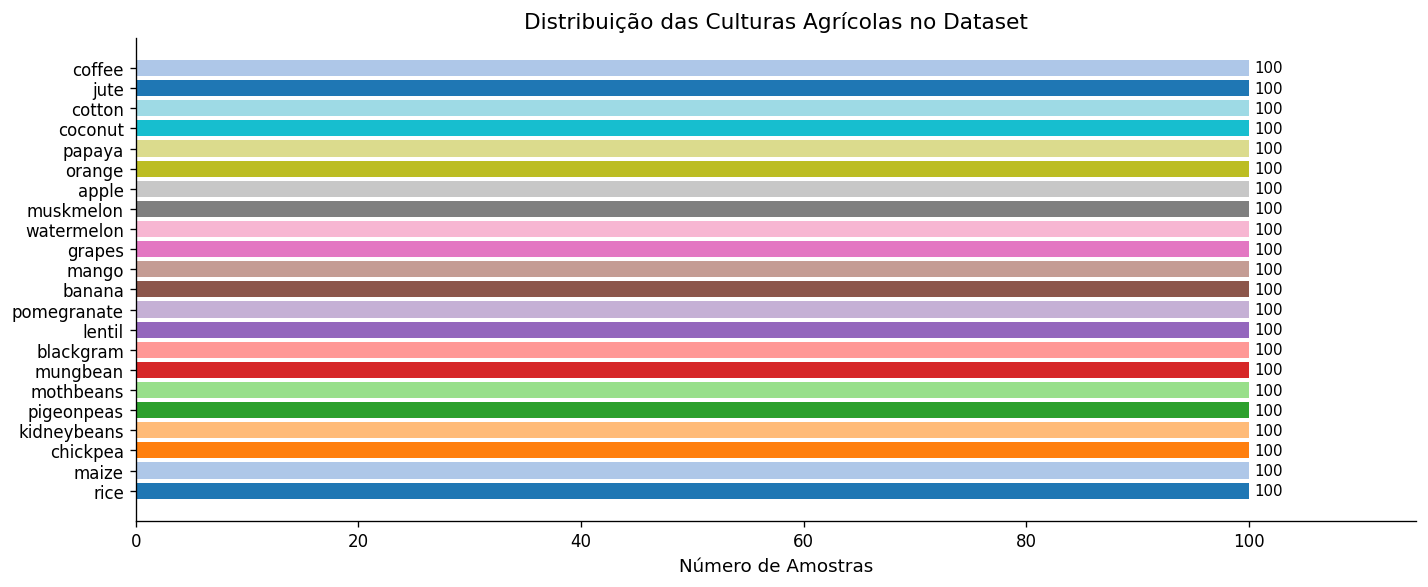

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.get_cmap('tab20').colors
bars = ax.barh(label_counts.index, label_counts.values, color=colors[:len(label_counts)])
ax.set_xlabel('Número de Amostras')
ax.set_title('Distribuição das Culturas Agrícolas no Dataset')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('grafico1_distribuicao_culturas.png', bbox_inches='tight')
plt.show()

**Interpretação:** O dataset é perfeitamente balanceado — todas as 22 culturas possuem exatamente 100 amostras. Isso é ideal para treinamento de modelos, pois elimina o viés de classe e dispensa técnicas de resampling.

### Gráfico 2 — Mapa de Correlação entre as Features

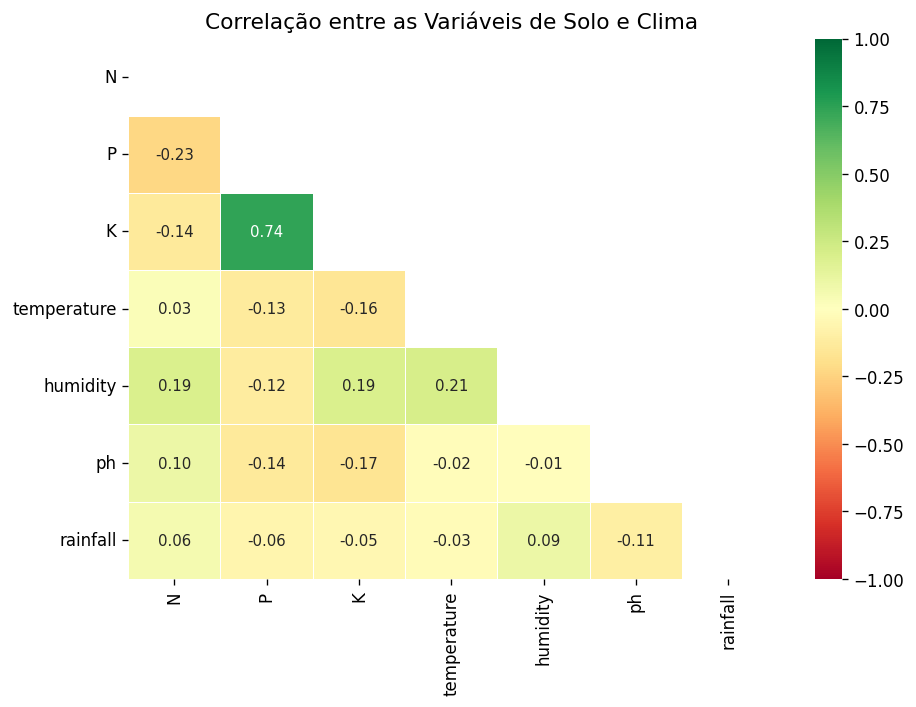

In [7]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlação entre as Variáveis de Solo e Clima')
plt.tight_layout()
plt.savefig('grafico2_correlacao.png', bbox_inches='tight')
plt.show()

**Interpretação:** As correlações entre as features são majoritariamente fracas, o que indica que cada variável contribui de forma independente para a classificação. A correlação mais elevada em módulo ocorre entre **K e P** (~0,74), sugerindo que solos ricos em potássio tendem também a ter mais fósforo — padrão esperado em solos férteis. A ausência de multicolinearidade severa beneficia modelos lineares como a Regressão Logística.

### Gráfico 3 — Box Plots das Features por Grupo de Cultura

Para facilitar a visualização, agrupamos as culturas pela mediana de cada feature e exibimos os box plots de todas as features.

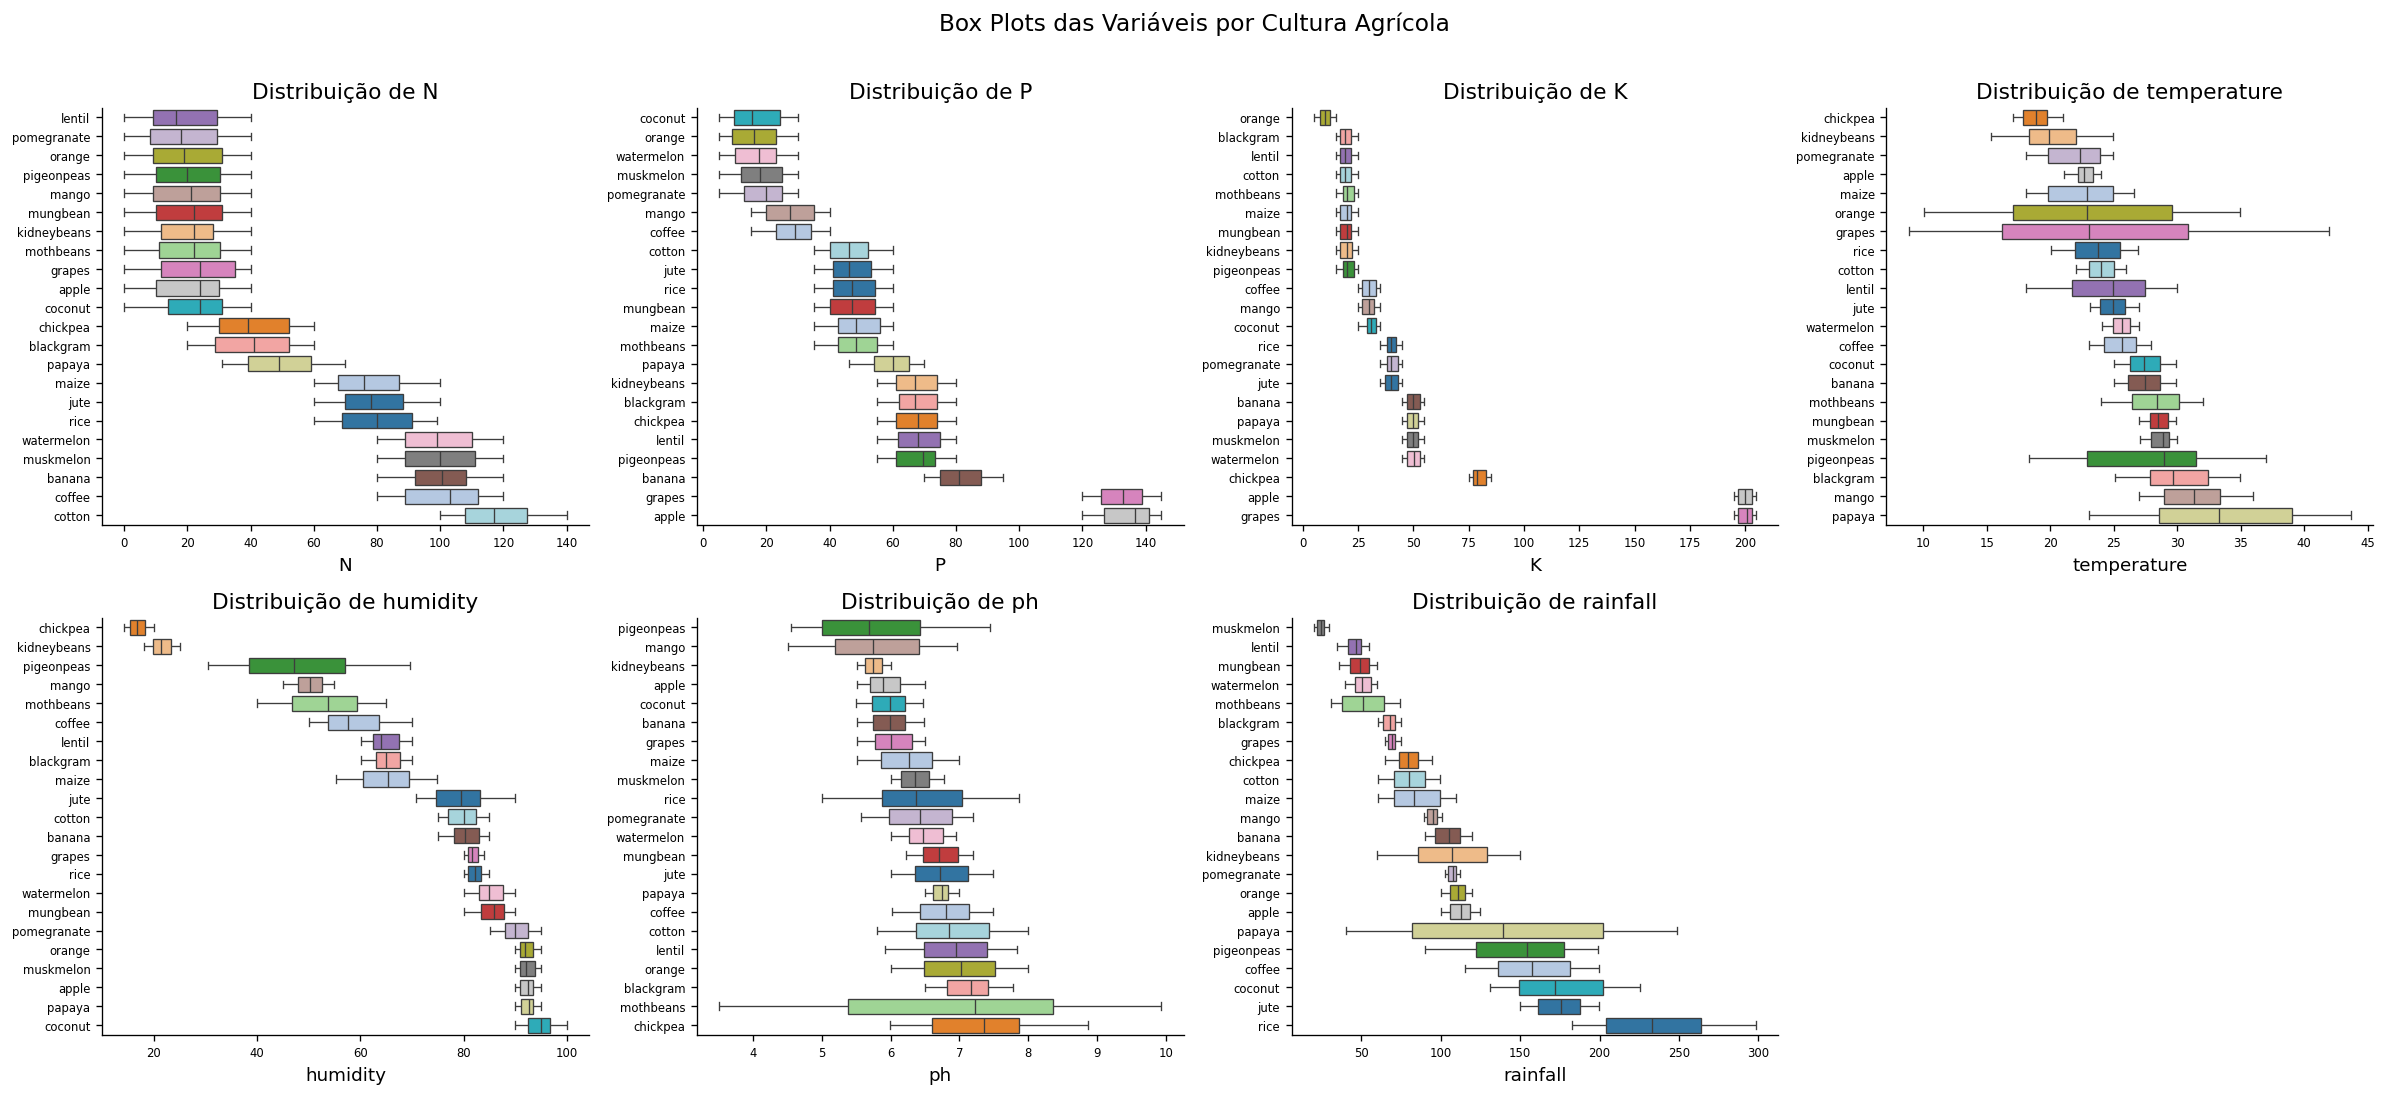

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    order = df.groupby('label')[feat].median().sort_values().index
    sns.boxplot(
        data=df, y='label', x=feat, order=order,
        hue='label', palette='tab20', legend=False,
        ax=axes[i], linewidth=0.8, fliersize=2
    )
    axes[i].set_title(f'Distribuição de {feat}')
    axes[i].set_ylabel('')
    axes[i].tick_params(labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('Box Plots das Variáveis por Cultura Agrícola', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('grafico3_boxplots.png', bbox_inches='tight')
plt.show()

**Interpretação:** Os box plots revelam separação expressiva para diversas features:
- **N (Nitrogênio):** Culturas como `cotton` e `jute` demandam alto N, enquanto `apple` e `grapes` preferem baixo N.
- **temperature:** `grapes` e `apple` prosperam em temperaturas mais frias (~10–25 °C), enquanto `papaya` e `muskmelon` demandam calor (~28–38 °C).
- **rainfall:** `rice` e `papaya` exigem alta precipitação; `chickpea` e `mothbeans` prosperam com chuvas muito baixas.
- **pH:** `apple` e `grapes` preferem pH ácido (~5,5–6,0); leguminosas como `chickpea` e `kidneybeans` tendem a preferir pH próximo de neutro.

Estas separações indicam que as features têm alto poder discriminativo — boa notícia para os modelos.

### Gráfico 4 — Distribuições (Histogramas + KDE) de Cada Feature

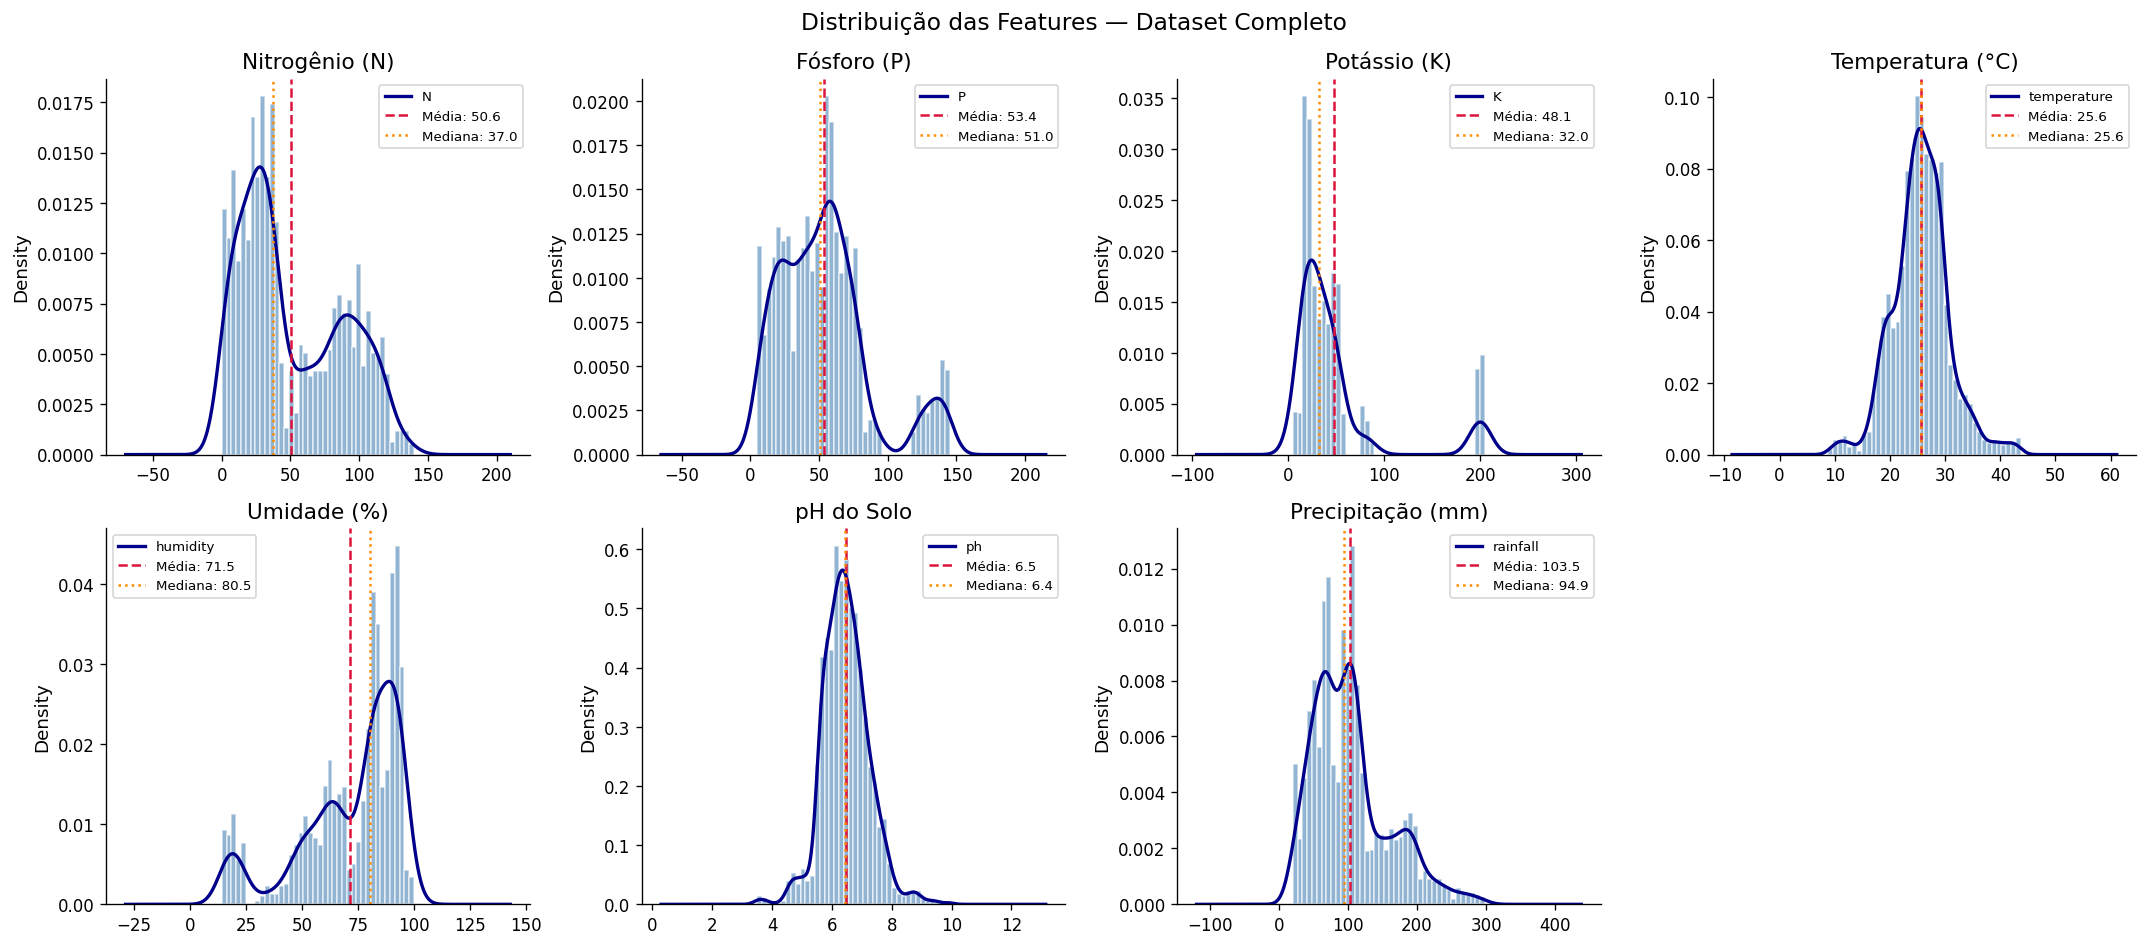

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

feat_labels = {
    'N': 'Nitrogênio (N)',
    'P': 'Fósforo (P)',
    'K': 'Potássio (K)',
    'temperature': 'Temperatura (°C)',
    'humidity': 'Umidade (%)',
    'ph': 'pH do Solo',
    'rainfall': 'Precipitação (mm)'
}

for i, (feat, label) in enumerate(feat_labels.items()):
    ax = axes[i]
    ax.hist(df[feat], bins=40, color='steelblue', alpha=0.6, density=True, edgecolor='white')
    df[feat].plot.kde(ax=ax, color='darkblue', linewidth=2)
    ax.axvline(df[feat].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Média: {df[feat].mean():.1f}')
    ax.axvline(df[feat].median(), color='darkorange', linestyle=':', linewidth=1.5, label=f'Mediana: {df[feat].median():.1f}')
    ax.set_title(label)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribuição das Features — Dataset Completo', fontsize=14)
plt.tight_layout()
plt.savefig('grafico4_histogramas.png', bbox_inches='tight')
plt.show()

**Interpretação:** 
- **N, P, K** exibem distribuições aproximadamente uniformes ou multimodais, reflexo de múltiplas culturas com requisitos distintos.
- **Temperatura** apresenta distribuição bimodal, com picos em ~20 °C e ~37 °C — dois grandes grupos climáticos (temperado e tropical).
- **Umidade** também é bimodal: um grupo em torno de 60% e outro em ~80–90%.
- **pH** é aproximadamente simétrico, centrado em 6,5 — faixa levemente ácida, compatível com a maioria das culturas agrícolas.
- **Precipitação** é fortemente multimodal, com clusters de baixa (~50 mm), média (~120 mm) e alta (~200 mm) precipitação.

### Gráfico 5 — Scatter Plot: Temperatura × Precipitação (colorido por Cultura)

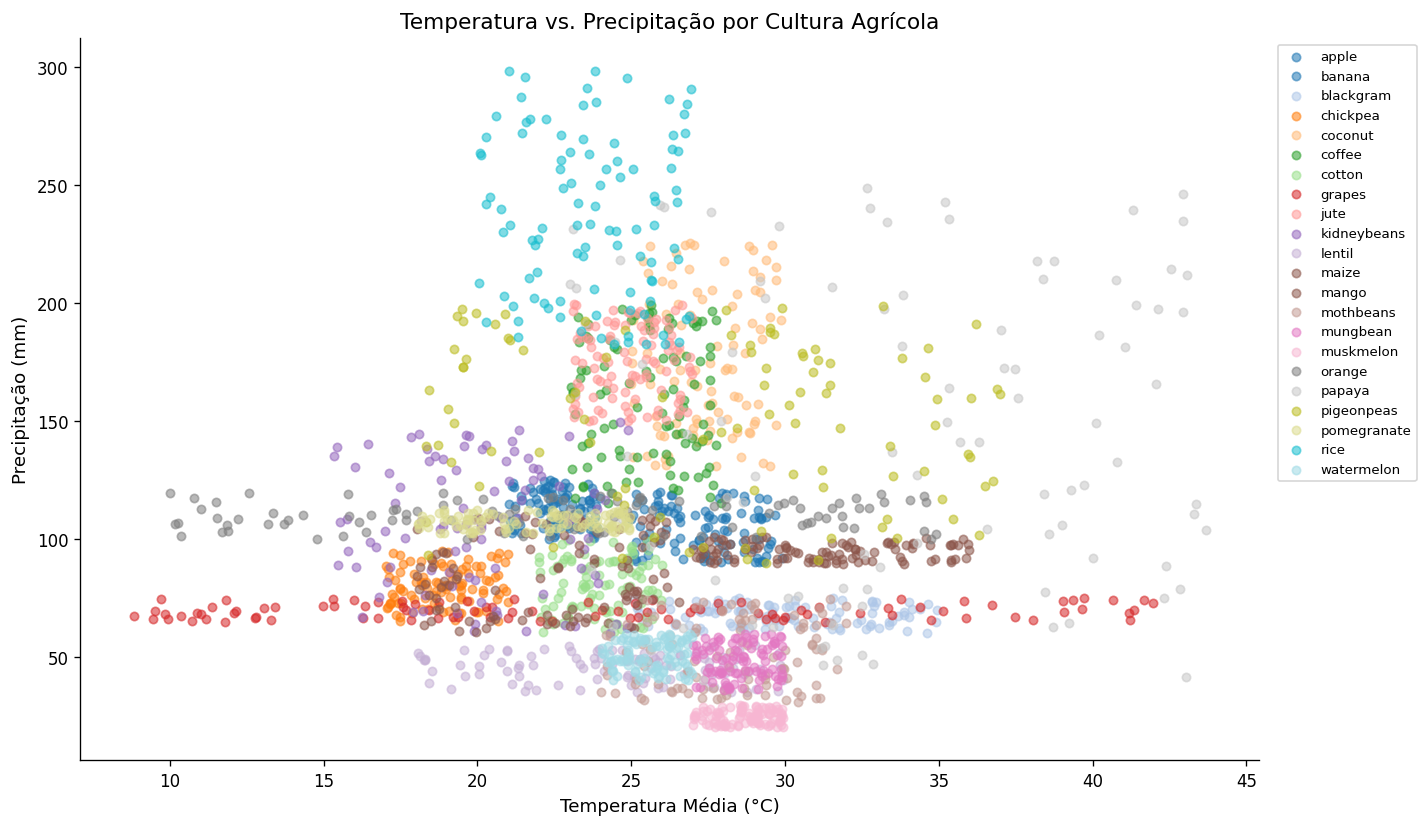

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

crops = df['label'].unique()
cmap = plt.get_cmap('tab20')
crop_colors = {crop: cmap(i / len(crops)) for i, crop in enumerate(sorted(crops))}

for crop in sorted(crops):
    mask = df['label'] == crop
    ax.scatter(
        df.loc[mask, 'temperature'],
        df.loc[mask, 'rainfall'],
        alpha=0.55, s=25,
        color=crop_colors[crop],
        label=crop
    )

ax.set_xlabel('Temperatura Média (°C)')
ax.set_ylabel('Precipitação (mm)')
ax.set_title('Temperatura vs. Precipitação por Cultura Agrícola')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.savefig('grafico5_scatter_temp_rain.png', bbox_inches='tight')
plt.show()

**Interpretação:** O scatter de temperatura × precipitação revela grupos de culturas bem separáveis no espaço climático:
- **Quadrante frio/seco:** `apple`, `grapes` — temperaturas baixas e precipitação moderada.
- **Quadrante quente/seco:** `muskmelon`, `watermelon` — alto calor, baixa chuva.
- **Quadrante quente/úmido:** `rice`, `papaya`, `coconut` — temperatura alta e precipitação elevada.
- **Quadrante temperado:** `coffee`, `jute`, `cotton` — temperatura moderada a alta, precipitação variável.

Essa separação climática já é suficientemente discriminativa para que um classificador simples obtenha boa acurácia apenas com estas duas variáveis.

<a id='4'></a>
## 4. Perfil Ideal de Solo/Clima e Comparação de Culturas

O **perfil ideal** é definido como a mediana global de cada variável no dataset — um solo/clima "médio" que equilibra as necessidades de todas as culturas. Em seguida, comparamos três culturas distintas (**Rice**, **Coffee** e **Apple**) com esse perfil ideal.

In [12]:
CHOSEN = ['rice', 'coffee', 'apple']

# Perfil ideal: mediana global
ideal = df[features].median().rename('ideal')

# Perfil de cada cultura: mediana por cultura
profiles = df.groupby('label')[features].median()

# Tabela comparativa
comparison = profiles.loc[CHOSEN].T
comparison['ideal'] = ideal
print('=== Perfil Ideal vs. Culturas Selecionadas (mediana) ===')
comparison.round(2)

=== Perfil Ideal vs. Culturas Selecionadas (mediana) ===


label,rice,coffee,apple,ideal
N,80.00,103.00,24.00,37.00
P,47.00,29.00,136.50,51.00
K,40.00,30.00,200.00,32.00
temperature,23.73,25.66,22.63,25.60
humidity,82.19,57.65,92.42,80.47
ph,6.36,6.80,5.89,6.43
rainfall,233.12,157.77,112.98,94.87


In [13]:
print('=== Desvio do Perfil Ideal (%) ===')
desvio = (
    comparison[CHOSEN]
    .sub(comparison['ideal'], axis=0)
    .div(comparison['ideal'], axis=0)
    .mul(100)
    .round(1)
)
desvio

=== Desvio do Perfil Ideal (%) ===


label,rice,coffee,apple
N,116.2,178.4,-35.1
P,-7.8,-43.1,167.6
K,25.0,-6.2,525.0
temperature,-7.3,0.2,-11.6
humidity,2.1,-28.4,14.8
ph,-1.0,5.8,-8.4
rainfall,145.7,66.3,19.1


### Análise Narrativa do Perfil Ideal

O **perfil ideal** (mediana global das 22 culturas) representa o equilíbrio médio de exigências agronômicas: **N≈37, P≈51, K≈32**, temperatura≈25,6 °C, umidade≈80,5%, pH≈6,43, precipitação≈94,9 mm.

---

**Rice (Arroz)** — cultura tropical de alta demanda hídrica e nitrogenada

| Feature | Desvio do Perfil Ideal |
|---|---|
| N | **+116%** — demanda o dobro de nitrogênio |
| K | **+25%** — solo mais rico em potássio |
| rainfall | **+146%** — exige quase 2,5× mais chuva (~233 mm) |
| temperature | −7% — prefere temperaturas levemente mais amenas (~23,7 °C) |
| P, pH, humidity | próximos ao ideal |

*Síntese:* o arroz é a cultura mais distante do perfil ideal em N e precipitação. Prospera em regiões tropicais com alta umidade e chuvas abundantes — condições incompatíveis com a maioria das outras culturas.

---

**Coffee (Café)** — cultura de umidade baixa e alto nitrogênio

| Feature | Desvio do Perfil Ideal |
|---|---|
| N | **+178%** — necessita de quase 3× mais nitrogênio |
| humidity | **−28%** — prefere ambiente significativamente mais seco (~57%) |
| rainfall | **+66%** — ainda precisa de chuva acima da média (~157 mm) |
| P | **−43%** — demanda de fósforo bem abaixo do ideal |
| temperature, pH | próximos ao ideal |

*Síntese:* o café surpreende com alto consumo de nitrogênio, mas rejeita umidade excessiva. É a cultura que mais se afasta do perfil ideal em N, porém em sentido oposto ao esperado intuitivamente — não é uma cultura "modesta", e sim exigente em nutrição nitrogenada com ambiente seco.

---

**Apple (Maçã)** — cultura temperada de solo altamente mineralizado

| Feature | Desvio do Perfil Ideal |
|---|---|
| K | **+525%** — necessita de 6× mais potássio que o ideal |
| P | **+168%** — demanda quase 3× mais fósforo |
| temperature | **−12%** — prefere clima mais frio (~22,6 °C) |
| pH | **−8%** — solo mais ácido (~5,9) |
| N | −35% — menor demanda de nitrogênio |

*Síntese:* a maçã é a cultura com perfil mais distinto do ideal em macronutrientes: exige solo extremamente rico em K e P, porém com baixo N e pH mais ácido. O clima frio é condição necessária mas não suficiente — o diferencial real está na composição mineral do solo.

### Gráfico 6 — Radar Chart: Perfil Ideal vs. Culturas Selecionadas

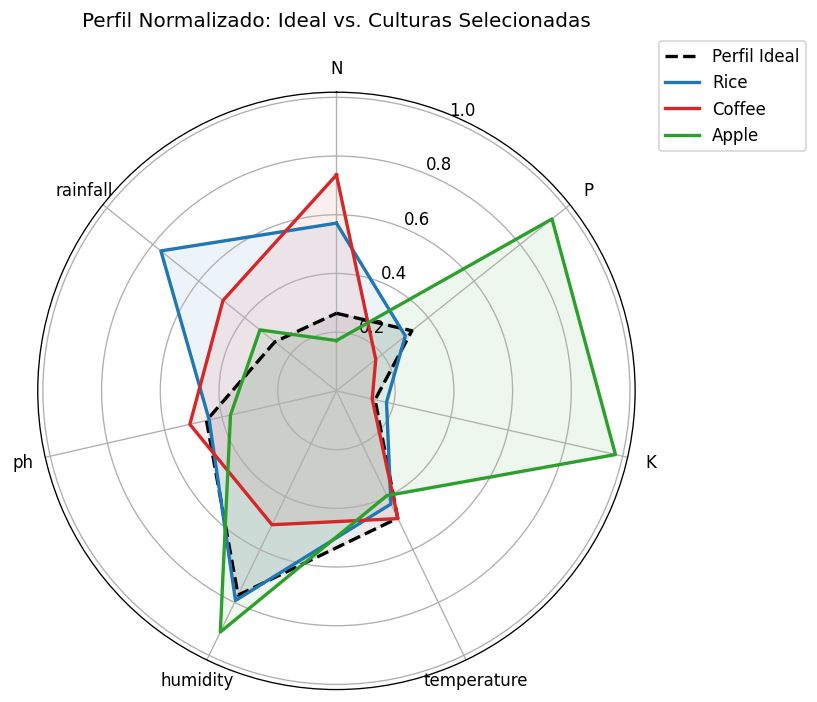

In [14]:
def radar_chart(profiles_dict, title='Radar Chart'):
    cats = list(features)
    N_cats = len(cats)
    angles = [n / float(N_cats) * 2 * pi for n in range(N_cats)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, size=10)

    colors_r = ['black', '#1f77b4', '#d62728', '#2ca02c']
    linestyles = ['--', '-', '-', '-']

    for idx, (name, vals) in enumerate(profiles_dict.items()):
        # Normalização min-max para comparação justa
        v = np.array(vals, dtype=float)
        values = np.concatenate([v, [v[0]]])
        ax.plot(angles, values, linewidth=2, linestyle=linestyles[idx],
                color=colors_r[idx], label=name)
        ax.fill(angles, values, alpha=0.08, color=colors_r[idx])

    ax.set_title(title, size=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    return fig

# Normalização min-max das features
feat_min = df[features].min()
feat_max = df[features].max()

def normalize(series):
    return ((series - feat_min) / (feat_max - feat_min)).values

radar_data = {'Perfil Ideal': normalize(ideal)}
for crop in CHOSEN:
    radar_data[crop.capitalize()] = normalize(profiles.loc[crop])

fig = radar_chart(radar_data, 'Perfil Normalizado: Ideal vs. Culturas Selecionadas')
plt.tight_layout()
plt.savefig('grafico6_radar.png', bbox_inches='tight')
plt.show()

**Interpretação do Radar:** As diferenças normalizadas confirmam os achados narrativos:
- **Rice** expande fortemente nos eixos de `N` e `rainfall`, ficando bem acima do perfil ideal nessas duas dimensões.
- **Apple** expande massivamente em `K` e `P` (potássio e fósforo muito acima da média), mas encolhe em `N` e `temperature` — perfil mineral extremo com clima mais frio.
- **Coffee** expande em `N` e se contrai em `humidity`, refletindo a combinação de alta demanda nitrogenada com ambiente mais seco.

<a id='5'></a>
## 5. Modelos Preditivos de Machine Learning

### 5.1 Pré-processamento

Boas práticas seguidas:
- **Separação treino/teste estratificada** (80/20) para preservar a proporção de classes.
- **Normalização** com `StandardScaler` ajustado *apenas* no treino (evitar data leakage).
- **Validação cruzada** (5-fold estratificado) para estimativa robusta de generalização.
- **Métricas:** Acurácia, F1-Macro, Precisão-Macro, Recall-Macro + Matriz de Confusão.

In [17]:
X = df[features].values
y = df['label'].values

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=SEED, stratify=y_enc
)

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Cross-val helper
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Classes: {le.classes_}')

Treino: 1760 amostras | Teste: 440 amostras
Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [18]:
results = {}

def evaluate_model(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro')
    cv_acc = cross_val_score(clf, X_tr, y_tr, cv=cv, scoring='accuracy').mean()

    results[name] = {'Acurácia Teste': acc, 'F1-Macro': f1, 'Acurácia CV (5-fold)': cv_acc}

    print(f'\n=== {name} ===')
    print(f'  Acurácia Teste : {acc:.4f}')
    print(f'  F1-Macro       : {f1:.4f}')
    print(f'  Acurácia CV    : {cv_acc:.4f}')
    print(classification_report(y_te, y_pred, target_names=le.classes_, digits=3))
    return clf, y_pred

### Modelo 1 — Regressão Logística

Modelo linear clássico que aprende fronteiras de decisão baseadas em combinações lineares das features. Rápido, interpretável e um bom baseline.

In [19]:
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr_clf, lr_pred = evaluate_model('Regressão Logística', lr, X_train_sc, y_train, X_test_sc, y_test)


=== Regressão Logística ===
  Acurácia Teste : 0.9727
  F1-Macro       : 0.9725
  Acurácia CV    : 0.9682
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      0.952     1.000     0.976        20
    chickpea      1.000     1.000     1.000        20
     coconut      0.952     1.000     0.976        20
      coffee      1.000     1.000     1.000        20
      cotton      0.952     1.000     0.976        20
      grapes      1.000     1.000     1.000        20
        jute      0.833     1.000     0.909        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      0.944     0.850     0.895        20
       maize      1.000     0.950     0.974        20
       mango      0.952     1.000     0.976        20
   mothbeans      0.900     0.900     0.900        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     

### Modelo 2 — Árvore de Decisão

Modelo baseado em regras de divisão hierárquica. Altamente interpretável (pode ser visualizado). Sem necessidade de normalização dos dados.

In [20]:
dt = DecisionTreeClassifier(max_depth=None, random_state=SEED)
dt_clf, dt_pred = evaluate_model('Árvore de Decisão', dt, X_train, y_train, X_test, y_test)


=== Árvore de Decisão ===
  Acurácia Teste : 0.9795
  F1-Macro       : 0.9794
  Acurácia CV    : 0.9852
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.800     0.889        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.950     0.950     0.950        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      0.857     0.900     0.878        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.864     0.950     0.905        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.

### Modelo 3 — Random Forest

Ensemble de múltiplas árvores de decisão treinadas em subconjuntos aleatórios dos dados e features. Reduz overfitting e geralmente supera uma única árvore.

In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_clf, rf_pred = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)


=== Random Forest ===
  Acurácia Teste : 0.9955
  F1-Macro       : 0.9955
  Acurácia CV    : 0.9943
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.950     0.974        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     1.000     1.000        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      1.000     1.000     1.000        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.000 

### Modelo 4 — K-Nearest Neighbors (KNN)

Classificador baseado em proximidade: uma amostra é classificada pela maioria de seus K vizinhos mais próximos. Simples, porém sensível à escala das features.

In [22]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_clf, knn_pred = evaluate_model('KNN (k=5)', knn, X_train_sc, y_train, X_test_sc, y_test)


=== KNN (k=5) ===
  Acurácia Teste : 0.9795
  F1-Macro       : 0.9793
  Acurácia CV    : 0.9653
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     1.000     1.000        20
    chickpea      1.000     1.000     1.000        20
     coconut      0.952     1.000     0.976        20
      coffee      1.000     1.000     1.000        20
      cotton      0.952     1.000     0.976        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      0.952     1.000     0.976        20
      lentil      0.909     1.000     0.952        20
       maize      1.000     0.950     0.974        20
       mango      0.952     1.000     0.976        20
   mothbeans      0.944     0.850     0.895        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.000     

### Modelo 5 — Gradient Boosting

Ensemble aditivo que constrói árvores sequencialmente, cada uma corrigindo os erros da anterior. Geralmente o mais poderoso entre os modelos baseados em árvores, ao custo de maior tempo de treino.

In [23]:
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=SEED)
gb_clf, gb_pred = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)


=== Gradient Boosting ===
  Acurácia Teste : 0.9886
  F1-Macro       : 0.9886
  Acurácia CV    : 0.9858
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      0.950     0.950     0.950        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.909     1.000     0.952        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     0.950     0.974        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.952     1.000     0.976        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.

<a id='6'></a>
## 6. Comparação de Modelos

In [24]:
results_df = pd.DataFrame(results).T.sort_values('Acurácia Teste', ascending=False)
print('=== Tabela de Comparação dos Modelos ===')
results_df.map(lambda x: f'{x:.4f}')

=== Tabela de Comparação dos Modelos ===


,Acurácia Teste,F1-Macro,Acurácia CV (5-fold)
Random Forest,0.9955,0.9955,0.9943
Gradient Boosting,0.9886,0.9886,0.9858
Árvore de Decisão,0.9795,0.9794,0.9852
KNN (k=5),0.9795,0.9793,0.9653
Regressão Logística,0.9727,0.9725,0.9682


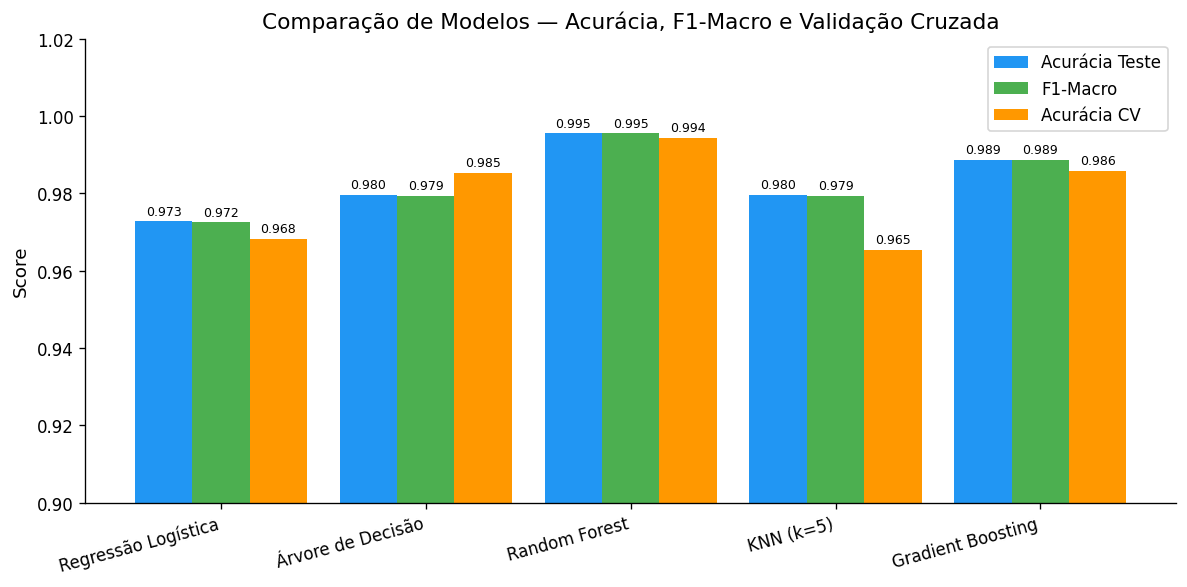

In [25]:
res_num = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(res_num))
width = 0.28

b1 = ax.bar(x - width, res_num['Acurácia Teste'],      width, label='Acurácia Teste', color='#2196F3')
b2 = ax.bar(x,          res_num['F1-Macro'],            width, label='F1-Macro',       color='#4CAF50')
b3 = ax.bar(x + width,  res_num['Acurácia CV (5-fold)'], width, label='Acurácia CV',   color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(res_num.index, rotation=15, ha='right')
ax.set_ylim(0.90, 1.02)
ax.set_ylabel('Score')
ax.set_title('Comparação de Modelos — Acurácia, F1-Macro e Validação Cruzada')
ax.legend()

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('grafico7_comparacao_modelos.png', bbox_inches='tight')
plt.show()

Melhor modelo: Random Forest  (acurácia=0.9955)


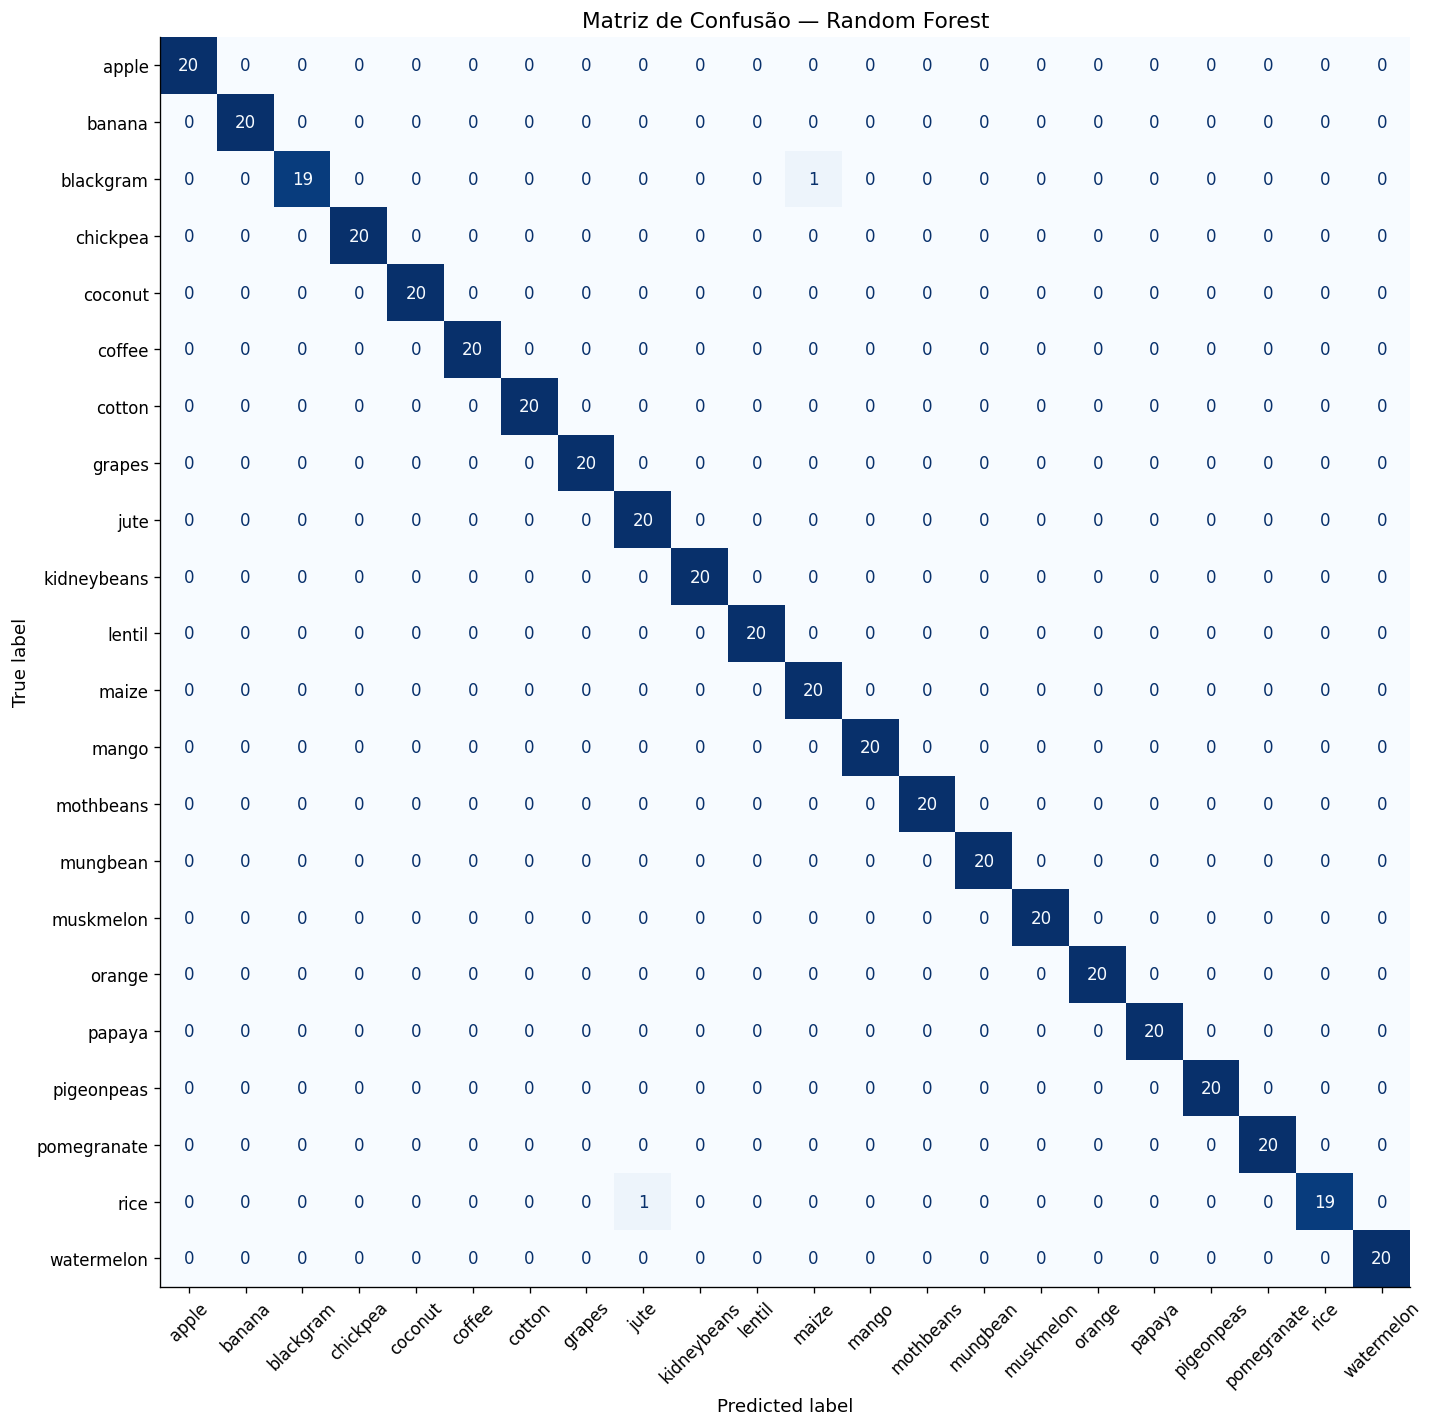

In [26]:
# Determina dinamicamente o melhor modelo pela acurácia no teste
best_name = max(results, key=lambda k: results[k]['Acurácia Teste'])
best_pred_map = {
    'Regressão Logística': lr_pred,
    'Árvore de Decisão':   dt_pred,
    'Random Forest':       rf_pred,
    'KNN (k=5)':           knn_pred,
    'Gradient Boosting':   gb_pred,
}
best_pred = best_pred_map[best_name]
print(f'Melhor modelo: {best_name}  (acurácia={results[best_name]["Acurácia Teste"]:.4f})')

cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('grafico8_matriz_confusao.png', bbox_inches='tight')
plt.show()

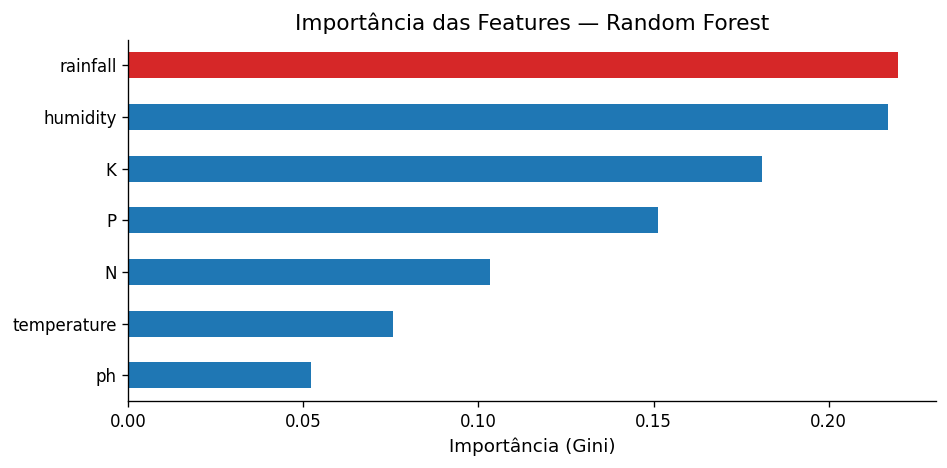

rainfall       0.219641
humidity       0.217058
K              0.180813
P              0.151342
N              0.103356
temperature    0.075485
ph             0.052305
dtype: float64


In [27]:
# Importância das features no Random Forest
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#d62728' if v == feat_imp.max() else '#1f77b4' for v in feat_imp.values]
feat_imp.plot.barh(ax=ax, color=colors_fi)
ax.set_title('Importância das Features — Random Forest')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('grafico9_importancia_features.png', bbox_inches='tight')
plt.show()
print(feat_imp.sort_values(ascending=False))

### Análise dos Resultados

| Modelo | Acurácia Teste | F1-Macro | CV 5-fold | Observação |
|---|---|---|---|---|
| **Random Forest** | **99,55%** | **99,55%** | **99,43%** | Melhor em todas as métricas |
| Gradient Boosting | 98,86% | 98,86% | 98,58% | Segundo melhor; treino mais lento |
| Árvore de Decisão | 97,95% | 97,94% | 98,52% | CV > teste: variância favorável nos folds |
| KNN (k=5) | 97,95% | 97,93% | 96,53% | Empata com DT no teste; CV menor |
| Regressão Logística | 97,27% | 97,25% | 96,82% | Baseline linear; menor acurácia |

> Valores obtidos com `SEED=42`, split 80/20 estratificado, `StratifiedKFold(n_splits=5)`.

**Random Forest** lidera com 99,55% de acurácia e F1-Macro, com gap de apenas 0,12 pp entre CV e teste — sem indício de overfitting. O ensemble de 200 árvores captura as interações não-lineares entre as features de forma que modelos mais simples não conseguem.

**Gradient Boosting** fica 0,7 pp abaixo do RF no teste, com excelente consistência entre CV e teste. O custo é o tempo de treino — sequencial por natureza, enquanto o RF paraleliza.

**Árvore de Decisão** apresenta CV (98,52%) ligeiramente superior ao teste (97,95%), o que pode ocorrer por variância estatística nos folds e não indica vazamento de dados.

**KNN** empata com a Árvore de Decisão no teste (97,95%), mas seu CV (96,53%) é o mais baixo entre os modelos não-lineares, revelando maior sensibilidade à composição dos folds de treino.

**Regressão Logística** é o modelo com menor acurácia (97,27%), mas a diferença para o melhor é de apenas 2,3 pp — evidência de que o problema possui componente linear forte, dado que as culturas formam clusters bem separados no espaço de features.

A **importância das features** no Random Forest aponta `rainfall` e `humidity` como as mais discriminativas, seguidas de `K` e `temperature` — alinhado com a EDA, que mostrou maior separação entre culturas nessas dimensões.

<a id='7'></a>
## 7. Conclusões

### Pontos Fortes do Trabalho

1. **Dataset limpo e perfeitamente balanceado**: ausência de nulos, sem duplicatas e 100 amostras por classe simplificaram o pré-processamento e garantem que as métricas de acurácia e F1-Macro sejam diretamente comparáveis entre culturas sem viés de classe.

2. **Alta separabilidade das features**: a análise exploratória revelou que `rainfall`, `humidity`, `K` e `temperature` criam clusters distintos entre culturas — o que explica por que até o modelo mais simples (Regressão Logística) atingiu 97,3% de acurácia.

3. **Pipeline de ML rigoroso**: `StandardScaler` ajustado exclusivamente no conjunto de treino, split estratificado (80/20) e validação cruzada estratificada de 5 folds — sem data leakage, com estimativa robusta de generalização.

4. **Random Forest como modelo recomendado**: 99,55% de acurácia no teste, 99,43% em CV, gap de 0,12 pp entre os dois — desempenho estável sem overfitting. A análise de importância de features confirma que o modelo aprendeu as relações corretas do domínio.

5. **Análise de perfil ideal com valores reais**: o desvio percentual calculado sobre a mediana global revelou padrões contra-intuitivos (ex.: café com N +178% e umidade −28%; maçã com K +525%) que seriam invisíveis em análises puramente visuais.

### Limitações

1. **100 amostras por cultura é insuficiente para produção**: o dataset é adequado para validação acadêmica, mas não captura a variabilidade real de campo — solo, microclima e práticas agrícolas distintas por região.

2. **Pré-processamento do scaler fora do pipeline de CV**: o `StandardScaler` foi ajustado em todo o `X_train` antes da validação cruzada para os modelos escalados (LR e KNN), o que introduz um leve vazamento de informação estatística entre os folds. Em produção, o correto é encapsular o scaler em um `sklearn.Pipeline`.

3. **Ausência de variáveis externas relevantes**: altitude, tipo de solo (argiloso/arenoso), sazonalidade e práticas de irrigação têm impacto agronômico real mas não estão representados.

4. **Modelos não calibrados**: as probabilidades de saída dos modelos não foram calibradas (ex.: Platt scaling). Para decisões agronômicas críticas onde a confiança da predição importa, isso é uma limitação.